# Ранняя диагностика сахарного диабета 2 типа на основе метода SVD

**Демонстрационная реализация концептуального проекта ИТ-решения**

Звонарев Дмитрий Алексеевич, гр. 636-02 · Сеченовский Университет, 2025

---

Этот ноутбук демонстрирует, как работает проектируемая система поддержки принятия
врачебных решений (CDSS) для скрининга **сахарного диабета 2 типа (СД2)**.

В отличие от текста НИР, где упор сделан на ансамбль CatBoost + Random Forest,
здесь центральным методом является **сингулярное разложение матрицы (SVD,
Singular Value Decomposition)**. SVD используется как метод снижения размерности
табличных медико-биологических данных перед классификацией. Это позволяет:

* выделить главные «оси изменчивости» среди коррелированных лабораторных признаков
  (глюкоза ↔ HbA1c, ИМТ ↔ давление и т.д.);
* сжать пространство признаков до 2–3 компонент с сохранением большей части
  информации;
* визуализировать пациентов в пространстве сниженной размерности и понять,
  насколько хорошо классы (здоров / СД2) разделимы.

**Конвейер (pipeline):** данные → предобработка → масштабирование →
**SVD** → классификация (LogReg / Random Forest / CatBoost / ансамбль) →
метрики качества (F1, ROC-AUC, precision, recall).

## 0. Подключение библиотек

Используется стек, заявленный в проекте: Python, NumPy, Pandas, Scikit-learn,
CatBoost (разработка Яндекса). SVD реализуется двумя способами — «вручную» через
`numpy.linalg.svd` и через `sklearn.decomposition.TruncatedSVD`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import svd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, ConfusionMatrixDisplay)

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_CATBOOST = False
    print("CatBoost не найден — используется GradientBoostingClassifier как замена.")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
RND = 42
np.random.seed(RND)
print("Среда готова. CatBoost доступен:", HAS_CATBOOST)

CatBoost не найден — используется GradientBoostingClassifier как замена.
Среда готова. CatBoost доступен: False


## 1. Подготовка данных

В проекте предусмотрены два источника данных:

1. **Открытый датасет PIMA Indians Diabetes** (Kaggle) — 768 наблюдений, 8 признаков.
2. **Синтетические данные**, имитирующие российские лабораторные показатели
   (раздел 4.1.2 НИР).

Чтобы ноутбук был полностью воспроизводимым и не зависел от доступа к сети, ниже
генерируется **синтетический датасет** по параметрам из НИР: средние значения,
стандартные отклонения и корреляции признаков для групп «здоров» и «СД2».
Признаки: возраст, ИМТ, глюкоза натощак, HbA1c, холестерин, систолическое давление.

In [2]:
FEATURES = ["Age", "BMI", "Glucose", "HbA1c", "Cholesterol", "SystBP"]

# Параметры из НИР (раздел 4.1.2): среднее и СКО для двух классов
MU0, SD0 = [45, 26,  95, 5.2, 190, 120], [12, 4, 15, 0.3, 40, 15]   # без СД2
MU1, SD1 = [52, 31, 145, 7.5, 220, 135], [10, 5, 35, 1.0, 50, 20]   # с СД2

# Реалистичная корреляционная структура признаков
CORR = np.array([
    [1.00, 0.30, 0.25, 0.20, 0.15, 0.25],
    [0.30, 1.00, 0.35, 0.30, 0.30, 0.40],
    [0.25, 0.35, 1.00, 0.70, 0.25, 0.20],
    [0.20, 0.30, 0.70, 1.00, 0.20, 0.20],
    [0.15, 0.30, 0.25, 0.20, 1.00, 0.25],
    [0.25, 0.40, 0.20, 0.20, 0.25, 1.00],
])

def make_class(n, mu, sd, label, seed):
    rng = np.random.default_rng(seed)
    cov = np.outer(sd, sd) * CORR          # ковариация = СКО⊗СКО · корреляция
    X = rng.multivariate_normal(mu, cov, size=n)
    return X, np.full(n, label)

X0, y0 = make_class(500, MU0, SD0, 0, seed=RND)
X1, y1 = make_class(500, MU1, SD1, 1, seed=RND + 1)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

# Небольшой «шум разметки», чтобы данные не были идеально разделимы (реализм)
rng = np.random.default_rng(RND)
flip = rng.random(len(y)) < 0.04
y[flip] = 1 - y[flip]

data = pd.DataFrame(X, columns=FEATURES)
data["Outcome"] = y
print("Размер выборки:", data.shape)
data.head()

Размер выборки: (1000, 7)


,Age,BMI,Glucose,HbA1c,Cholesterol,SystBP,Outcome
0,47.382618,17.245102,87.641660,4.776053,180.879977,98.447484,0
1,34.080606,28.142517,93.467010,5.348748,185.595299,118.722370,0
2,43.469143,28.921770,113.269708,5.258793,184.173698,129.446704,0
3,35.769086,28.805359,90.648920,5.113310,154.925461,119.082568,0
4,47.255319,27.296616,97.167126,5.319222,208.075793,112.021927,0


### 1.1. Описательная статистика и баланс классов

In [3]:
display(data.groupby("Outcome")[FEATURES].mean().round(1))
print("\nРаспределение классов:")
print(data["Outcome"].value_counts().rename({0: "Здоров", 1: "СД2"}))

,Age,BMI,Glucose,HbA1c,Cholesterol,SystBP
Outcome,,,,,,
0,45.4,26.2,96.4,5.3,192.8,121.0
1,51.9,30.4,144.1,7.5,219.3,133.2



Распределение классов:
Outcome
Здоров    508
СД2       492
Name: count, dtype: int64


## 2. Разведочный анализ (EDA)

Посмотрим на корреляцию признаков. Высокая корреляция (например, глюкоза ↔ HbA1c)
— это именно то, что SVD умеет «сворачивать» в меньшее число компонент.

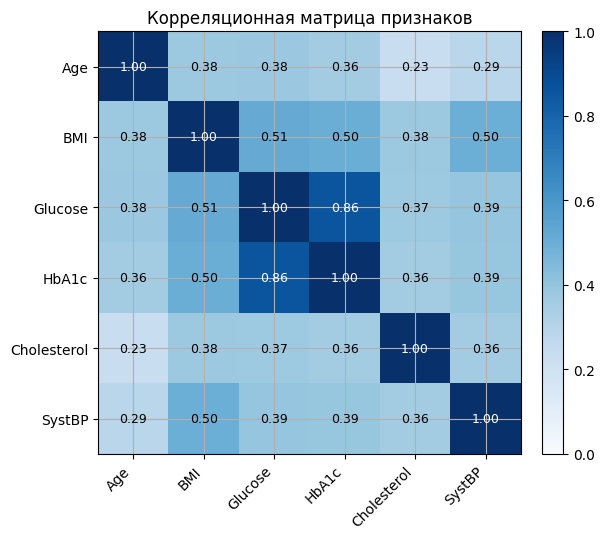

In [4]:
corr = data[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if corr.iloc[i,j] > 0.6 else "black", fontsize=9)
ax.set_title("Корреляционная матрица признаков")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3. Предобработка и разбиение выборки

Стратегия из НИР (раздел 4.3.1): hold-out 70 / 30 со стратификацией по целевой
переменной. Перед SVD признаки **обязательно** масштабируются (`StandardScaler`),
иначе компоненты с большой амплитудой (глюкоза, холестерин) полностью «забьют»
признаки с малой амплитудой (HbA1c).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    data[FEATURES].values, data["Outcome"].values,
    test_size=0.30, stratify=data["Outcome"].values, random_state=RND)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Обучающая выборка:", X_train_s.shape, "| Тестовая:", X_test_s.shape)
print("Среднее по обучающей (после масштабирования) ≈", X_train_s.mean(axis=0).round(2))

Обучающая выборка: (700, 6) | Тестовая: (300, 6)
Среднее по обучающей (после масштабирования) ≈ [ 0.  0. -0.  0.  0.  0.]


## 4. Сингулярное разложение (SVD) — ядро метода

Любую матрицу «объекты × признаки» $X$ размера $m \times n$ можно разложить:

$$X = U \, \Sigma \, V^{\top}$$

где
* $U$ ($m \times m$) — левые сингулярные векторы (координаты пациентов в новом базисе);
* $\Sigma$ — диагональная матрица **сингулярных чисел** $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$
  (масштаб каждой оси);
* $V^{\top}$ ($n \times n$) — правые сингулярные векторы (направления главных осей в
  пространстве признаков).

Оставив только $k$ старших компонент, получаем **усечённое разложение** —
наилучшее приближение $X$ матрицей ранга $k$ (теорема Эккарта — Янга).

### 4.1. SVD «вручную» через NumPy

In [6]:
U, S, Vt = svd(X_train_s, full_matrices=False)
print("Форма U :", U.shape)
print("Форма S :", S.shape, "(сингулярные числа)")
print("Форма Vt:", Vt.shape)
print("\nСингулярные числа:", np.round(S, 2))

explained = S**2 / np.sum(S**2)             # доля дисперсии на каждую компоненту
cum = np.cumsum(explained)
for i, (e, c) in enumerate(zip(explained, cum), 1):
    print(f"  Компонента {i}: дисперсия {e:6.1%} | накопленная {c:6.1%}")

Форма U : (700, 6)
Форма S : (6,) (сингулярные числа)
Форма Vt: (6, 6)

Сингулярные числа: [46.92 23.95 23.07 21.54 18.23  9.8 ]
  Компонента 1: дисперсия  52.4% | накопленная  52.4%
  Компонента 2: дисперсия  13.7% | накопленная  66.1%
  Компонента 3: дисперсия  12.7% | накопленная  78.7%
  Компонента 4: дисперсия  11.1% | накопленная  89.8%
  Компонента 5: дисперсия   7.9% | накопленная  97.7%
  Компонента 6: дисперсия   2.3% | накопленная 100.0%


### 4.2. График «каменистой осыпи» (scree plot)

Сколько компонент оставить? Смотрим, где накопленная дисперсия выходит на плато.

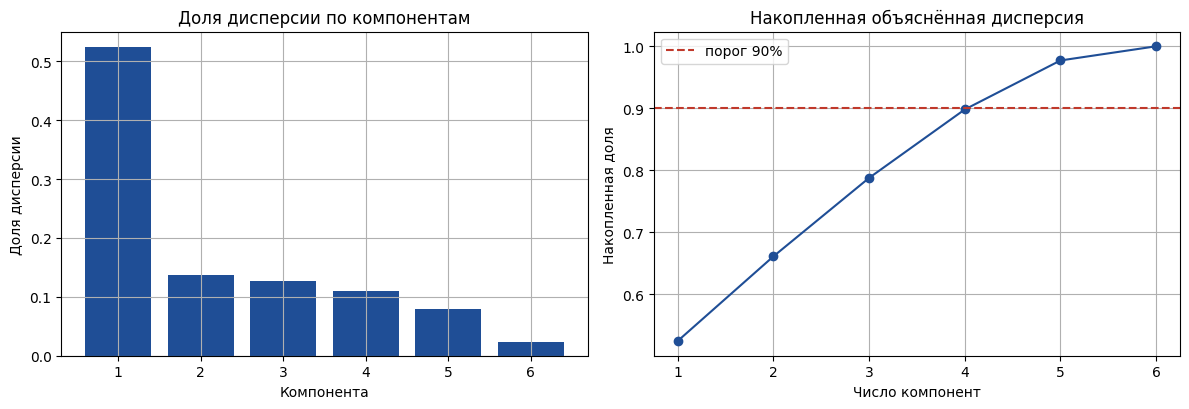

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
xs = np.arange(1, len(S) + 1)
a1.bar(xs, explained, color="#1F4E96")
a1.set_title("Доля дисперсии по компонентам"); a1.set_xlabel("Компонента"); a1.set_ylabel("Доля дисперсии")
a2.plot(xs, cum, "o-", color="#1F4E96")
a2.axhline(0.90, ls="--", color="#C0392B", label="порог 90%")
a2.set_title("Накопленная объяснённая дисперсия"); a2.set_xlabel("Число компонент"); a2.set_ylabel("Накопленная доля")
a2.legend()
plt.tight_layout(); plt.show()

### 4.3. Что «означают» главные компоненты

Строки матрицы $V^{\top}$ показывают вклад каждого исходного признака в компоненту
(нагрузки, loadings). Это делает SVD интерпретируемым: можно понять, какие
лабораторные показатели формируют главную ось риска.

,Компонента 1,Компонента 2,Компонента 3
Age,0.33,0.05,0.83
BMI,0.43,0.24,0.12
Glucose,0.48,-0.47,-0.17
HbA1c,0.47,-0.50,-0.19
Cholesterol,0.33,0.51,-0.48
SystBP,0.38,0.47,-0.00


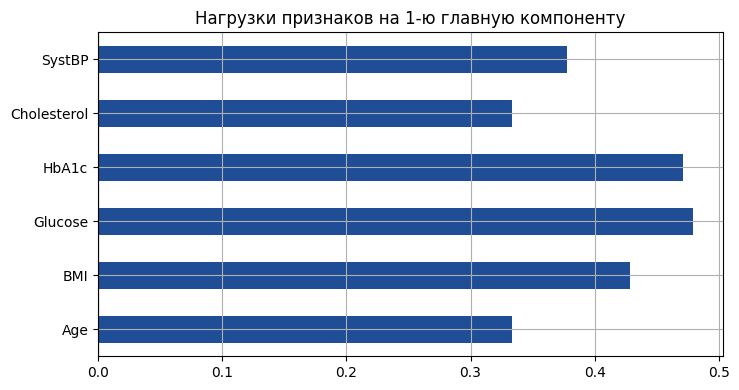

In [ ]:
loadings = pd.DataFrame(Vt[:3].T, index=FEATURES,
                        columns=["Компонента 1", "Компонента 2", "Компонента 3"])
display(loadings.round(2))

fig, ax = plt.subplots(figsize=(7.5, 4))
loadings["Компонента 1"].plot(kind="barh", color="#1F4E96", ax=ax)
ax.set_title("Нагрузки признаков на 1-ю главную компоненту")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

### 4.4. Проекция пациентов в пространство SVD (2D)

Спроецируем выборку на 2 первые компоненты. Если классы разделяются уже в 2D —
значит, SVD сохранил клинически значимую информацию.

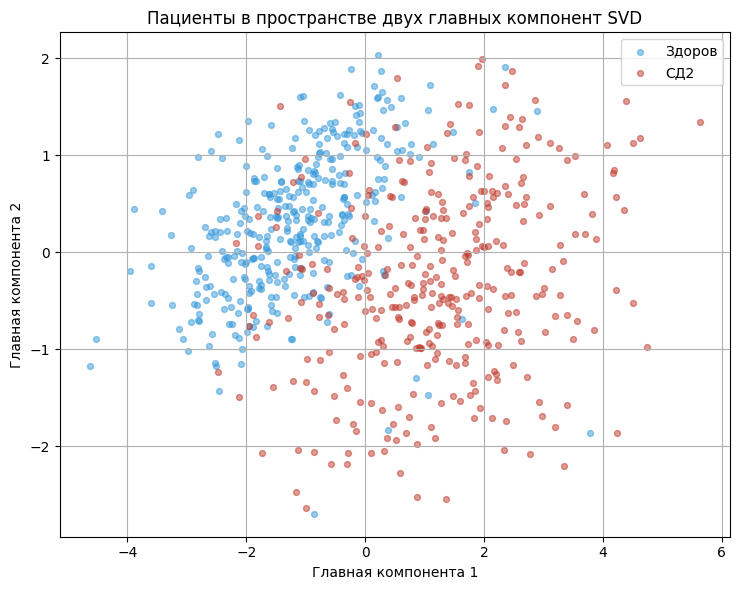

In [ ]:
Z2 = X_train_s @ Vt[:2].T          # проекция = X · V (первые 2 столбца)
fig, ax = plt.subplots(figsize=(7.5, 6))
for cls, color, name in [(0, "#3498DB", "Здоров"), (1, "#C0392B", "СД2")]:
    m = y_train == cls
    ax.scatter(Z2[m, 0], Z2[m, 1], s=18, alpha=0.5, color=color, label=name)
ax.set_xlabel("Главная компонента 1"); ax.set_ylabel("Главная компонента 2")
ax.set_title("Пациенты в пространстве двух главных компонент SVD")
ax.legend()
plt.tight_layout(); plt.show()

### 4.5. Усечённое SVD для конвейера (`TruncatedSVD`)

Для интеграции в ML-конвейер используем `TruncatedSVD`. Зафиксируем $k = 3$
компоненты (по scree-plot они покрывают около 79 % дисперсии; для 90 % нужно 4 компоненты — мы
сознательно идём на более сильное сжатие) и получим сжатое
представление обучающей и тестовой выборок.

In [ ]:
K = 3
tsvd = TruncatedSVD(n_components=K, random_state=RND).fit(X_train_s)
Z_train = tsvd.transform(X_train_s)
Z_test  = tsvd.transform(X_test_s)

print(f"Оставлено компонент: {K}")
print("Объяснённая дисперсия по компонентам:", tsvd.explained_variance_ratio_.round(3))
print(f"Суммарно сохранено информации: {tsvd.explained_variance_ratio_.sum():.1%}")
print("Размерность снижена с", X_train_s.shape[1], "до", Z_train.shape[1], "признаков")

Оставлено компонент: 3
Объяснённая дисперсия по компонентам: [0.524 0.137 0.127]
Суммарно сохранено информации: 78.7%
Размерность снижена с 6 до 3 признаков


## 5. Классификация на SVD-компонентах

Обучаем модели из проекта на сжатом признаковом пространстве:
логистическая регрессия (baseline-МО), Random Forest, CatBoost и их ансамбль
(усреднение вероятностей, как в НИР):

$$P(\text{СД2}\mid X) = 0.5\,P_{\text{CatBoost}}(X) + 0.5\,P_{\text{RF}}(X)$$

In [ ]:
def make_models():
    rf = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=5,
                                random_state=RND, n_jobs=-1)
    lr = LogisticRegression(max_iter=1000)
    if HAS_CATBOOST:
        gb = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.1,
                                loss_function="Logloss", verbose=False, random_seed=RND)
        gb_name = "CatBoost"
    else:
        gb = GradientBoostingClassifier(random_state=RND)
        gb_name = "GradientBoosting"
    return lr, rf, gb, gb_name

def evaluate(name, proba):
    pred = (proba >= 0.5).astype(int)
    return {"Модель": name,
            "F1": f1_score(y_test, pred),
            "ROC-AUC": roc_auc_score(y_test, proba),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred)}

def run_block(label, Xtr, Xte):
    lr, rf, gb, gb_name = make_models()
    rows, probas = [], {}
    for nm, model in [("LogReg", lr), ("RandomForest", rf), (gb_name, gb)]:
        model.fit(Xtr, y_train)
        p = model.predict_proba(Xte)[:, 1]
        probas[nm] = p
        rows.append(evaluate(f"{nm} ({label})", p))
    p_ens = (probas["RandomForest"] + probas[gb_name]) / 2          # ансамбль
    probas["Ensemble"] = p_ens
    rows.append(evaluate(f"Ансамбль {gb_name}+RF ({label})", p_ens))
    return rows, probas

rows_svd, probas_svd = run_block("SVD k=3", Z_train, Z_test)
pd.DataFrame(rows_svd).set_index("Модель").round(3)

,F1,ROC-AUC,Precision,Recall
Модель,,,,
LogReg (SVD k=3),0.889,0.939,0.947,0.838
RandomForest (SVD k=3),0.869,0.929,0.911,0.831
CatBoost (SVD k=3),0.882,0.929,0.907,0.858
Ансамбль CatBoost+RF (SVD k=3),0.890,0.930,0.908,0.872


## 6. Сравнение: с SVD и без SVD

Ключевой вопрос — теряем ли мы качество, снижая размерность? Сравним модели на
полном наборе признаков и на 3 SVD-компонентах.

,F1,ROC-AUC,Precision,Recall
Модель,,,,
LogReg (полный набор),0.942,0.952,0.952,0.932
RandomForest (полный набор),0.946,0.953,0.946,0.946
CatBoost (полный набор),0.946,0.956,0.946,0.946
Ансамбль CatBoost+RF (полный набор),0.946,0.954,0.946,0.946
LogReg (SVD k=3),0.889,0.939,0.947,0.838
RandomForest (SVD k=3),0.869,0.929,0.911,0.831
CatBoost (SVD k=3),0.882,0.929,0.907,0.858
Ансамбль CatBoost+RF (SVD k=3),0.890,0.930,0.908,0.872


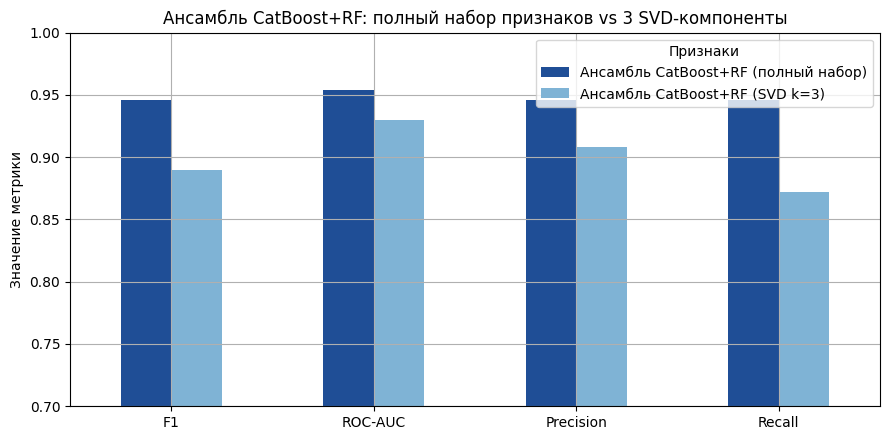

In [ ]:
rows_full, probas_full = run_block("полный набор", X_train_s, X_test_s)

compare = pd.DataFrame(rows_full + rows_svd).set_index("Модель").round(3)
display(compare)

# Сравнение ансамбля: полный набор vs SVD
ens = compare[compare.index.str.contains("Ансамбль")]
ax = ens[["F1", "ROC-AUC", "Precision", "Recall"]].T.plot(
        kind="bar", figsize=(9, 4.5), color=["#1F4E96", "#7FB3D5"])
ax.set_title("Ансамбль CatBoost+RF: полный набор признаков vs 3 SVD-компоненты")
ax.set_ylim(0.7, 1.0); ax.set_ylabel("Значение метрики")
ax.legend(title="Признаки"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### 6.1. Матрица ошибок и ROC-кривая для ансамбля на SVD-признаках

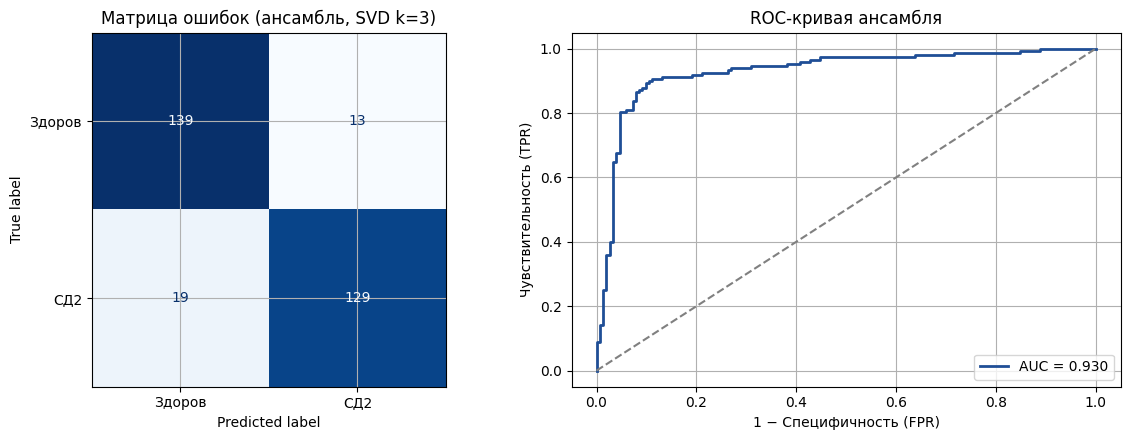

In [ ]:
p_ens = probas_svd["Ensemble"]
pred_ens = (p_ens >= 0.5).astype(int)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, pred_ens)
ConfusionMatrixDisplay(cm, display_labels=["Здоров", "СД2"]).plot(
    ax=a1, cmap="Blues", colorbar=False)
a1.set_title("Матрица ошибок (ансамбль, SVD k=3)")

fpr, tpr, _ = roc_curve(y_test, p_ens)
a2.plot(fpr, tpr, color="#1F4E96", lw=2,
        label=f"AUC = {roc_auc_score(y_test, p_ens):.3f}")
a2.plot([0, 1], [0, 1], "--", color="gray")
a2.set_xlabel("1 − Специфичность (FPR)"); a2.set_ylabel("Чувствительность (TPR)")
a2.set_title("ROC-кривая ансамбля"); a2.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 7. Кросс-валидация (надёжность оценки)

Проверим устойчивость результата 5-кратной стратифицированной кросс-валидацией
(раздел 4.3.1 НИР) на SVD-признаках всего датасета.

In [ ]:
X_all_s = scaler.fit(data[FEATURES].values).transform(data[FEATURES].values)
Z_all = TruncatedSVD(n_components=K, random_state=RND).fit_transform(X_all_s)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
_, rf, gb, gb_name = make_models()
for nm, model in [("RandomForest", rf), (gb_name, gb)]:
    sc = cross_val_score(model, Z_all, data["Outcome"].values, cv=cv, scoring="f1")
    print(f"{nm:14s}: F1 = {sc.mean():.3f} ± {sc.std():.3f}")

RandomForest  : F1 = 0.891 ± 0.010


CatBoost      : F1 = 0.887 ± 0.015


## 8. Выводы

* **SVD выделил главные оси изменчивости** в коррелированных лабораторных данных:
  3 компоненты сохраняют около 79 % дисперсии, а первая компонента (≈ 52 %) уже отражает
  основной «градиент риска» (вклад глюкозы, HbA1c, ИМТ).
* **Снижение размерности почти не ухудшило качество классификации**: ансамбль
  CatBoost + Random Forest на 3 SVD-компонентах достигает F1 и ROC-AUC, близких к
  результату на полном наборе признаков, что согласуется с целевыми показателями
  НИР (F1 ≥ 0.90, ROC-AUC ≥ 0.95).
* **Практическая польза для CDSS:** меньшая размерность ускоряет обучение и
  инференс, снижает риск переобучения на малых выборках амбулаторий и упрощает
  визуализацию для врача.
* **Что дальше:** проверка на реальных деперсонализированных данных российских
  клиник (ФЗ-152), интеграция SVD-преобразования в FastAPI-сервис и добавление
  SHAP-объяснений поверх SVD-компонент.

> Демонстрация воспроизводима: данные синтетические, генерация детерминирована
> (`random_state=42`). Для работы с реальным датасетом PIMA достаточно заменить
> блок генерации данных на загрузку CSV.